<a href="https://colab.research.google.com/github/GGWILson-ops/MachineLearning/blob/main/weatherpred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/seattle-weather.csv')
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [ ]:
df = df.drop(['date'], axis=1)
df

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain
4,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain
1457,1.5,5.0,1.7,1.3,rain
1458,0.0,7.2,0.6,2.6,fog
1459,0.0,5.6,-1.0,3.4,sun


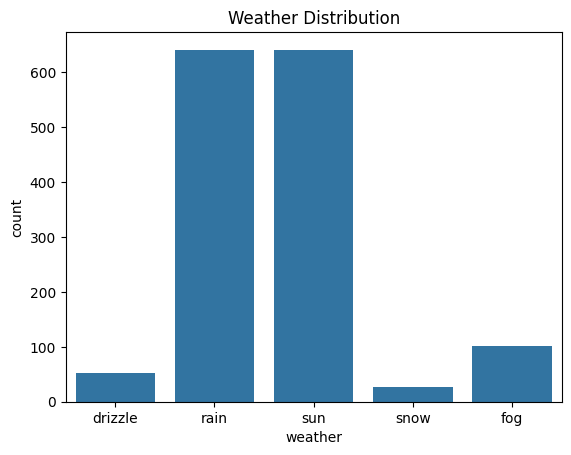

In [ ]:
sns.countplot(x='weather', data=df)
plt.title("Weather Distribution")
plt.show()

In [ ]:
encoder=LabelEncoder()
df['weather'] = encoder.fit_transform(df['weather'])
encoder

LabelEncoder()

In [ ]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

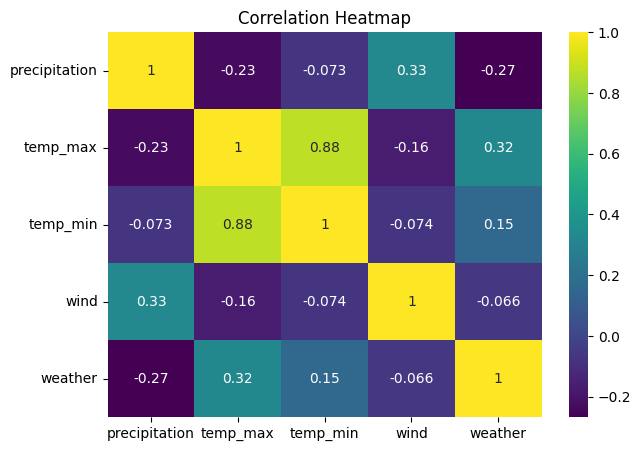

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df = df.drop(['temp_min','wind'], axis=1)
df

,precipitation,temp_max,weather
0,0.0,12.8,0
1,10.9,10.6,2
2,0.8,11.7,2
3,20.3,12.2,2
4,1.3,8.9,2
...,...,...,...
1456,8.6,4.4,2
1457,1.5,5.0,2
1458,0.0,7.2,1
1459,0.0,5.6,4


In [ ]:
X = df.drop(columns=['weather'])
y = df['weather']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
scaler=MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
with open("minmax_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
models=[KNeighborsClassifier(),GaussianNB(),DecisionTreeClassifier(),RandomForestClassifier(),AdaBoostClassifier(random_state=2),GradientBoostingClassifier(random_state=2),XGBClassifier(random_state=2, eval_metric='mlogloss')]
results = []

for model in models:
    print(model)
    if isinstance(model, KNeighborsClassifier):
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": type(model).__name__, "Accuracy": round(acc * 100, 2)})

    print(classification_report(y_test, y_pred, target_names=encoder.classes_))
    print("*" * 100)

KNeighborsClassifier()
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        11
         fog       0.21      0.15      0.18        20
        rain       0.95      0.83      0.88       129
        snow       0.00      0.00      0.00         5
         sun       0.69      0.84      0.75       128

    accuracy                           0.74       293
   macro avg       0.37      0.36      0.36       293
weighted avg       0.73      0.74      0.73       293

****************************************************************************************************
GaussianNB()
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00        11
         fog       0.00      0.00      0.00        20
        rain       0.96      0.91      0.93       129
        snow       0.00      0.00      0.00         5
         sun       0.75      1.00      0.86       128

    accuracy                           0.84     

In [ ]:
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

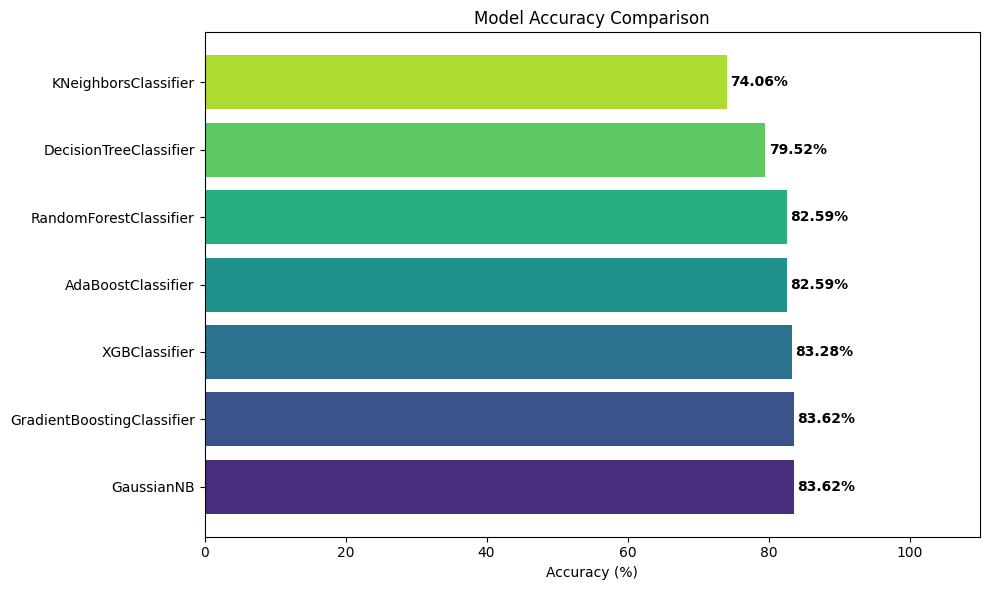

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.barh(results_df["Model"], results_df["Accuracy"], color=sns.color_palette("viridis", len(results_df)))
plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 110)
for bar, acc in zip(bars, results_df["Accuracy"]):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{acc}%", va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_acc  = results_df.iloc[0]["Accuracy"]
best_model = next(m for m in models if type(m).__name__ == best_name)

print(f"Best Model: {best_name} — Accuracy: {best_acc}%")

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

Best Model: GaussianNB — Accuracy: 83.62%
